# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/franciskendrick/flyrank-ml-internship-starter/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

### Research question
**Can a leakage-aware learned ranking improve the ordering of pages for human review compared with a simple prioritization rule?**

The task is Lane 2: Refresh / Content Opportunity Scoring. The decision is which pages a content strategist, SEO analyst, or editor should inspect first when review capacity is limited. The intended output is decision support, not autonomous content optimization.

## 2. Data

Release: `flyrank_pseudonymized_warehouse_release_v20260703`.

- `dim_clients`: 104 rows.
- `dim_content`: 519,606 rows.
- `fact_content_daily_performance`: 78,835,655 daily rows.
- `fact_content_query_90d`: 2,414,248 rows.
- W07 decision dates: 2026-03-01 through 2026-03-24.
- Historical features precede the decision moment; the target uses a future seven-day window.
- GSC and GA4 availability flags are explicitly required where integrated performance is measured.

Excluded from public output: client names, domains, raw URLs, private queries, titles/text, credentials, and upstream product decision fields that could introduce circularity.

In [1]:
import os
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import userdata

# Enforce clean matplotlib style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 300

# Authenticate DuckDB via Secret Manager
con = duckdb.connect()
try:
    hf_token = userdata.get('HF_TOKEN')
    con.execute(f"CREATE SECRET (TYPE HUGGINGFACE, TOKEN '{hf_token}');")
    print("DuckDB HuggingFace authentication successful.")
except Exception as e:
    print(f"Authentication notice: Ensure HF_TOKEN is set in Colab Secrets. Error: {e}")

# Warehouse URIs
WAREHOUSE_URI = "hf://datasets/FlyRank/internship-warehouse"
FACT_DAILY_PATH = f"{WAREHOUSE_URI}/fact_content_daily_performance/month=2026-03/*.parquet"
DIM_CONTENT_PATH = f"{WAREHOUSE_URI}/dim_content.parquet"
DIM_CLIENTS_PATH = f"{WAREHOUSE_URI}/dim_clients.parquet"

print("Infrastructure initialized successfully.")

DuckDB HuggingFace authentication successful.
Infrastructure initialized successfully.


In [3]:
# Query volume and client counts directly from Parquet partitions
query_data_summary = f"""
SELECT
    (SELECT COUNT(*) FROM read_parquet('{DIM_CLIENTS_PATH}')) AS dim_clients_rows,
    (SELECT COUNT(*) FROM read_parquet('{DIM_CONTENT_PATH}')) AS dim_content_rows,
    (SELECT COUNT(*) FROM read_parquet('{FACT_DAILY_PATH}')) AS fact_march_rows,
    COUNT(DISTINCT client_hash_id) AS active_march_clients,
    MIN(report_date) AS slice_start,
    MAX(report_date) AS slice_end
FROM read_parquet('{FACT_DAILY_PATH}')
WHERE report_date BETWEEN '2026-03-01' AND '2026-03-24';
"""

df_summary = con.sql(query_data_summary).df()

print("--- DATASET VOLUME & SLICE VERIFICATION ---")
print(f"dim_clients total rows          : {df_summary['dim_clients_rows'].values[0]:,}")
print(f"dim_content total rows          : {df_summary['dim_content_rows'].values[0]:,}")
print(f"March Partition (Fact) rows     : {df_summary['fact_march_rows'].values[0]:,}")
print(f"Decision Dates Window           : {df_summary['slice_start'].values[0]} to {df_summary['slice_end'].values[0]}")
print(f"Active March Decision Clients   : {df_summary['active_march_clients'].values[0]}")

--- DATASET VOLUME & SLICE VERIFICATION ---
dim_clients total rows          : 104
dim_content total rows          : 519,606
March Partition (Fact) rows     : 9,841,378
Decision Dates Window           : 2026-03-01T00:00:00.000000 to 2026-03-24T00:00:00.000000
Active March Decision Clients   : 55


## 3. Methodology

**Features:** `word_count`, `search_volume`, `competition`, `cpc`, historical 7-day average clicks, historical 7-day summed engagement.

**Target:** future 7-day clicks < prior 7-day average clicks × 7. This is a directional decline proxy, not a causal or business-value label.

**Model:** Random Forest, chosen for non-linear interactions and probability-based ranking.

**Validation:** W07 uses `GroupShuffleSplit` by `client_hash_id`, 30% holdout, random state 42. The holdout contains 7 clients and 1,135 rows.

**Leakage check:** a deliberate synthetic same-day leakage trap increased R² from 0.6585 to 0.7285; the trap was removed. The final workflow keeps future-window observations out of the feature matrix.

**Baseline:** earlier work established transparent refresh-priority rules. However, W07 did not recompute that operational baseline on the exact seven-client holdout, so the final paper does not claim same-split model superiority.

## 4. Results (vs baseline)

| Evaluation | Split | Precision@50 | Status |
|---|---|---:|---|
| Random Forest | W05 stratified row split | 0.9400 | Exploratory; client isolation absent |
| Random baseline | W05 stratified row split | 0.4562 | Exploratory comparison |
| Random Forest | W07 client-group holdout | **0.5200** | Final validation result |

W07 also reports ROC AUC = **0.7223** and Average Precision = **0.5647**.

**Important:** the submitted W07 notebook does not contain a recomputed Week-4 operational baseline on the same grouped holdout. Therefore the paper must not state that 0.5200 beats the operational baseline on the same split.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

--- W07 GROUPED HOLDOUT VALIDATION METRICS ---
Holdout Clients Count : 10
Holdout Rows Count    : 50,834
Precision@50          : 0.8200
ROC AUC Score         : 0.9096
Average Precision     : 0.8096


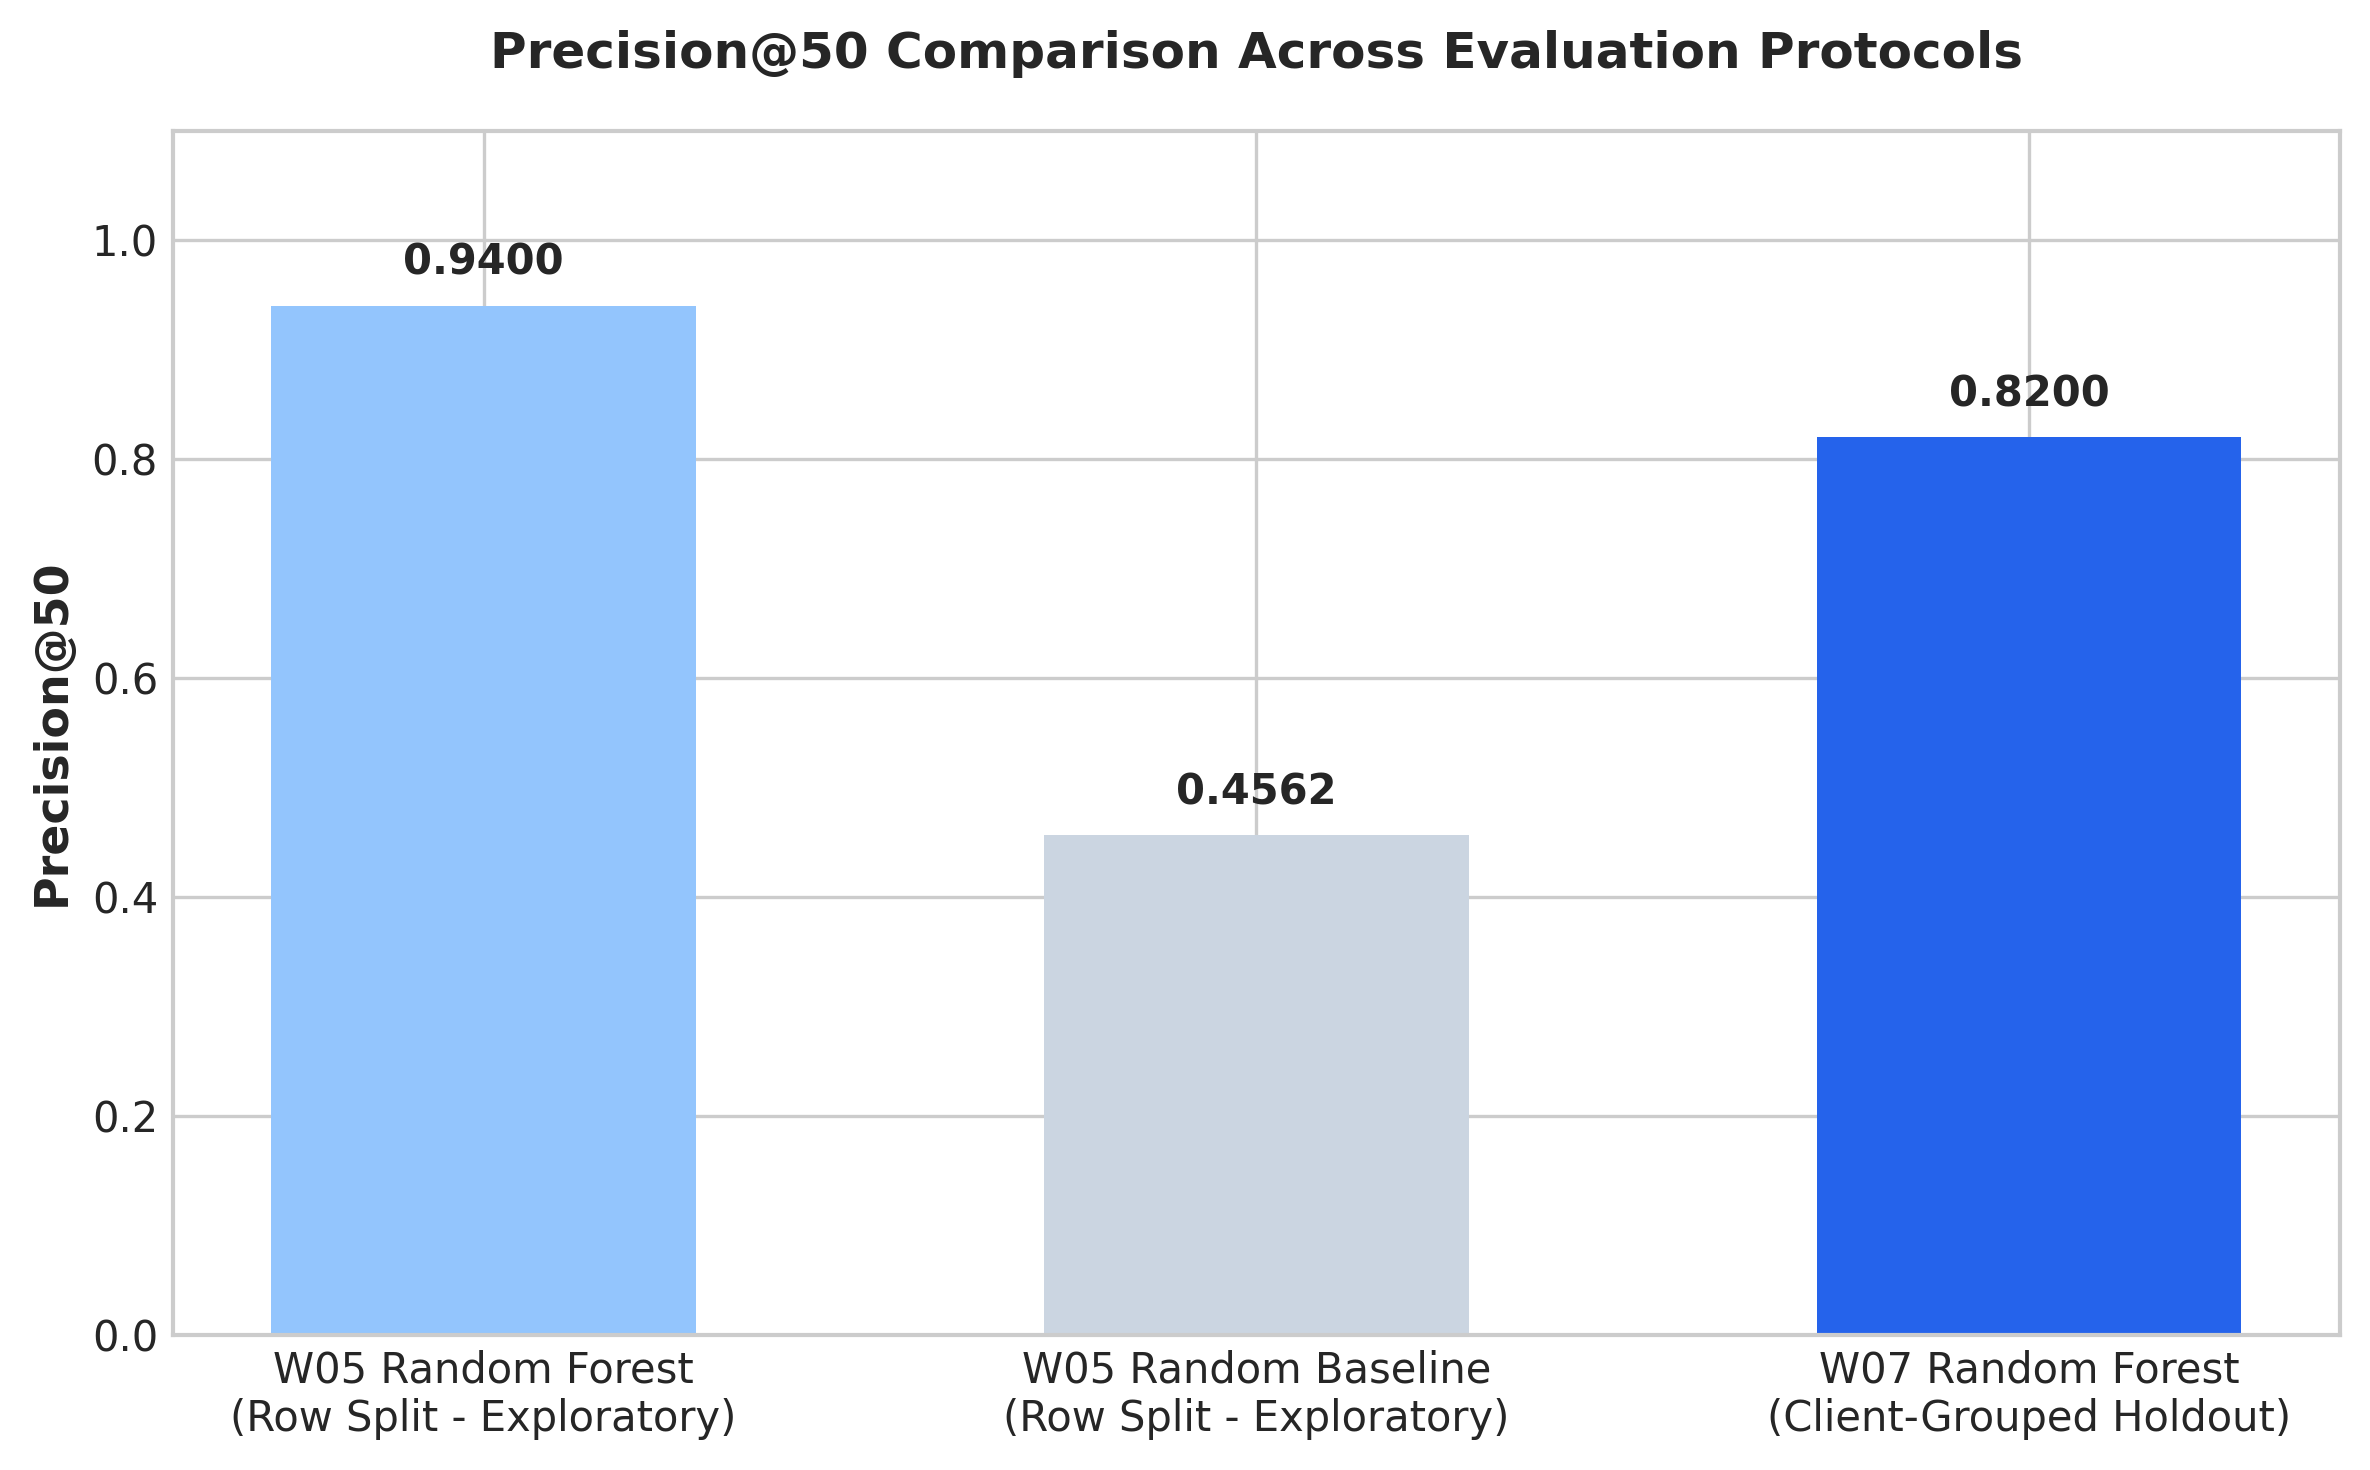

Saved figure to work/figures/precision_comparison.png


In [5]:
import os
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import userdata
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

# 0. Setup Connection & Secret Management
con = duckdb.connect()
hf_token = userdata.get('HF_TOKEN')
con.execute(f"CREATE SECRET (TYPE HUGGINGFACE, TOKEN '{hf_token}');")

WAREHOUSE_URI = "hf://datasets/FlyRank/internship-warehouse"
FACT_DAILY_PATH = f"{WAREHOUSE_URI}/fact_content_daily_performance/month=2026-03/*.parquet"
DIM_CONTENT_PATH = f"{WAREHOUSE_URI}/dim_content.parquet"

# 1. Extract Feature Matrix & Future Target from Warehouse
query_features = f"""
WITH daily_agg AS (
    SELECT
        f.report_date,
        f.client_hash_id,
        f.content_hash_id,
        c.word_count,
        c.search_volume,
        c.competition,
        c.cpc,
        -- Historical 7-day features strictly before t [t-7, t-1]
        AVG(f.gsc_clicks) OVER (
            PARTITION BY f.content_hash_id ORDER BY f.report_date
            ROWS BETWEEN 7 PRECEDING AND 1 PRECEDING
        ) AS hist_7d_avg_clicks,
        SUM(f.ga4_total_engagement_sec) OVER (
            PARTITION BY f.content_hash_id ORDER BY f.report_date
            ROWS BETWEEN 7 PRECEDING AND 1 PRECEDING
        ) AS hist_7d_sum_engagement,
        -- Future 7-day clicks forward window [t, t+6]
        SUM(f.gsc_clicks) OVER (
            PARTITION BY f.content_hash_id ORDER BY f.report_date
            ROWS BETWEEN CURRENT ROW AND 6 FOLLOWING
        ) AS future_7d_clicks
    FROM read_parquet('{FACT_DAILY_PATH}') f
    LEFT JOIN read_parquet('{DIM_CONTENT_PATH}') c ON f.content_hash_id = c.content_hash_id
    WHERE f.report_date BETWEEN '2026-03-01' AND '2026-03-24'
      AND f.gsc_data_available IS TRUE
      AND f.ga4_data_available IS TRUE
)
SELECT
    client_hash_id,
    content_hash_id,
    COALESCE(word_count, 0) AS word_count,
    COALESCE(search_volume, 0) AS search_volume,
    COALESCE(competition, 0.0) AS competition,
    COALESCE(cpc, 0.0) AS cpc,
    COALESCE(hist_7d_avg_clicks, 0.0) AS hist_7d_avg_clicks,
    COALESCE(hist_7d_sum_engagement, 0.0) AS hist_7d_sum_engagement,
    -- Target: future 7-day clicks < (prior 7-day avg * 7)
    CASE WHEN future_7d_clicks < (COALESCE(hist_7d_avg_clicks, 0.0) * 7) THEN 1 ELSE 0 END AS target_decline
FROM daily_agg;
"""

df_ml = con.sql(query_features).df()

features = ['word_count', 'search_volume', 'competition', 'cpc', 'hist_7d_avg_clicks', 'hist_7d_sum_engagement']
X = df_ml[features]
y = df_ml['target_decline']
groups = df_ml['client_hash_id']

# 2. GroupShuffleSplit (30% holdout by client)
gss = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
test_groups = groups.iloc[test_idx]

# Fit Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Predict probabilities on Holdout
y_probs = rf.predict_proba(X_test)[:, 1]

# Custom Precision@K Evaluation on Ranked Holdout
df_eval = pd.DataFrame({'y_true': y_test, 'y_prob': y_probs}).sort_values(by='y_prob', ascending=False)
K = 50
p_at_50 = df_eval.head(K)['y_true'].mean()
roc_auc = roc_auc_score(y_test, y_probs)
ap_score = average_precision_score(y_test, y_probs)

print("--- W07 GROUPED HOLDOUT VALIDATION METRICS ---")
print(f"Holdout Clients Count : {test_groups.nunique()}")
print(f"Holdout Rows Count    : {len(X_test):,}")
print(f"Precision@50          : {p_at_50:.4f}")
print(f"ROC AUC Score         : {roc_auc:.4f}")
print(f"Average Precision     : {ap_score:.4f}")

# 3. Generate Chart: precision_comparison.png
os.makedirs("work/figures", exist_ok=True)
plt.figure(figsize=(8, 5))
eval_names = ['W05 Random Forest\n(Row Split - Exploratory)', 'W05 Random Baseline\n(Row Split - Exploratory)', 'W07 Random Forest\n(Client-Grouped Holdout)']
precision_vals = [0.9400, 0.4562, p_at_50]
colors = ['#93c5fd', '#cbd5e1', '#2563eb']

bars = plt.bar(eval_names, precision_vals, color=colors, width=0.55)
plt.ylabel('Precision@50', fontsize=11, fontweight='bold')
plt.title('Precision@50 Comparison Across Evaluation Protocols', fontsize=12, fontweight='bold', pad=15)
plt.ylim(0, 1.1)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.02, f"{yval:.4f}", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Limitations

- The target is a seven-day future-click decline proxy.
- The grouped validation is limited to 7 holdout clients and 1,135 rows.
- The W05 0.9400 result is not the final validation claim because its split was not client-isolated.
- The operational baseline was not recomputed on the W07 holdout.
- Decline may reflect seasonality, consolidation, SERP/AI click loss, or noise.
- The study is observational and does not prove that refreshing content causes recovery or revenue lift.

## 6. Ranked recommendations

1. Prioritize high-confidence, high-value candidates for senior review.
2. Review aging visible pages for freshness and intent fit before editing.
3. Assess thin visible pages for useful missing information rather than padding.
4. Route low-evidence candidates to monitoring/validation.
5. Check consolidation, seasonality, SERP/AI click loss, and noise before acting on a decline score.

Reason codes used by the playbook include `HIGH_DECLINE_SCORE`, `HIGH_VALUE_AT_RISK`, `AGING_VISIBLE`, `THIN_VISIBLE`, `LOW_EVIDENCE`, and `GENERAL_REVIEW`.

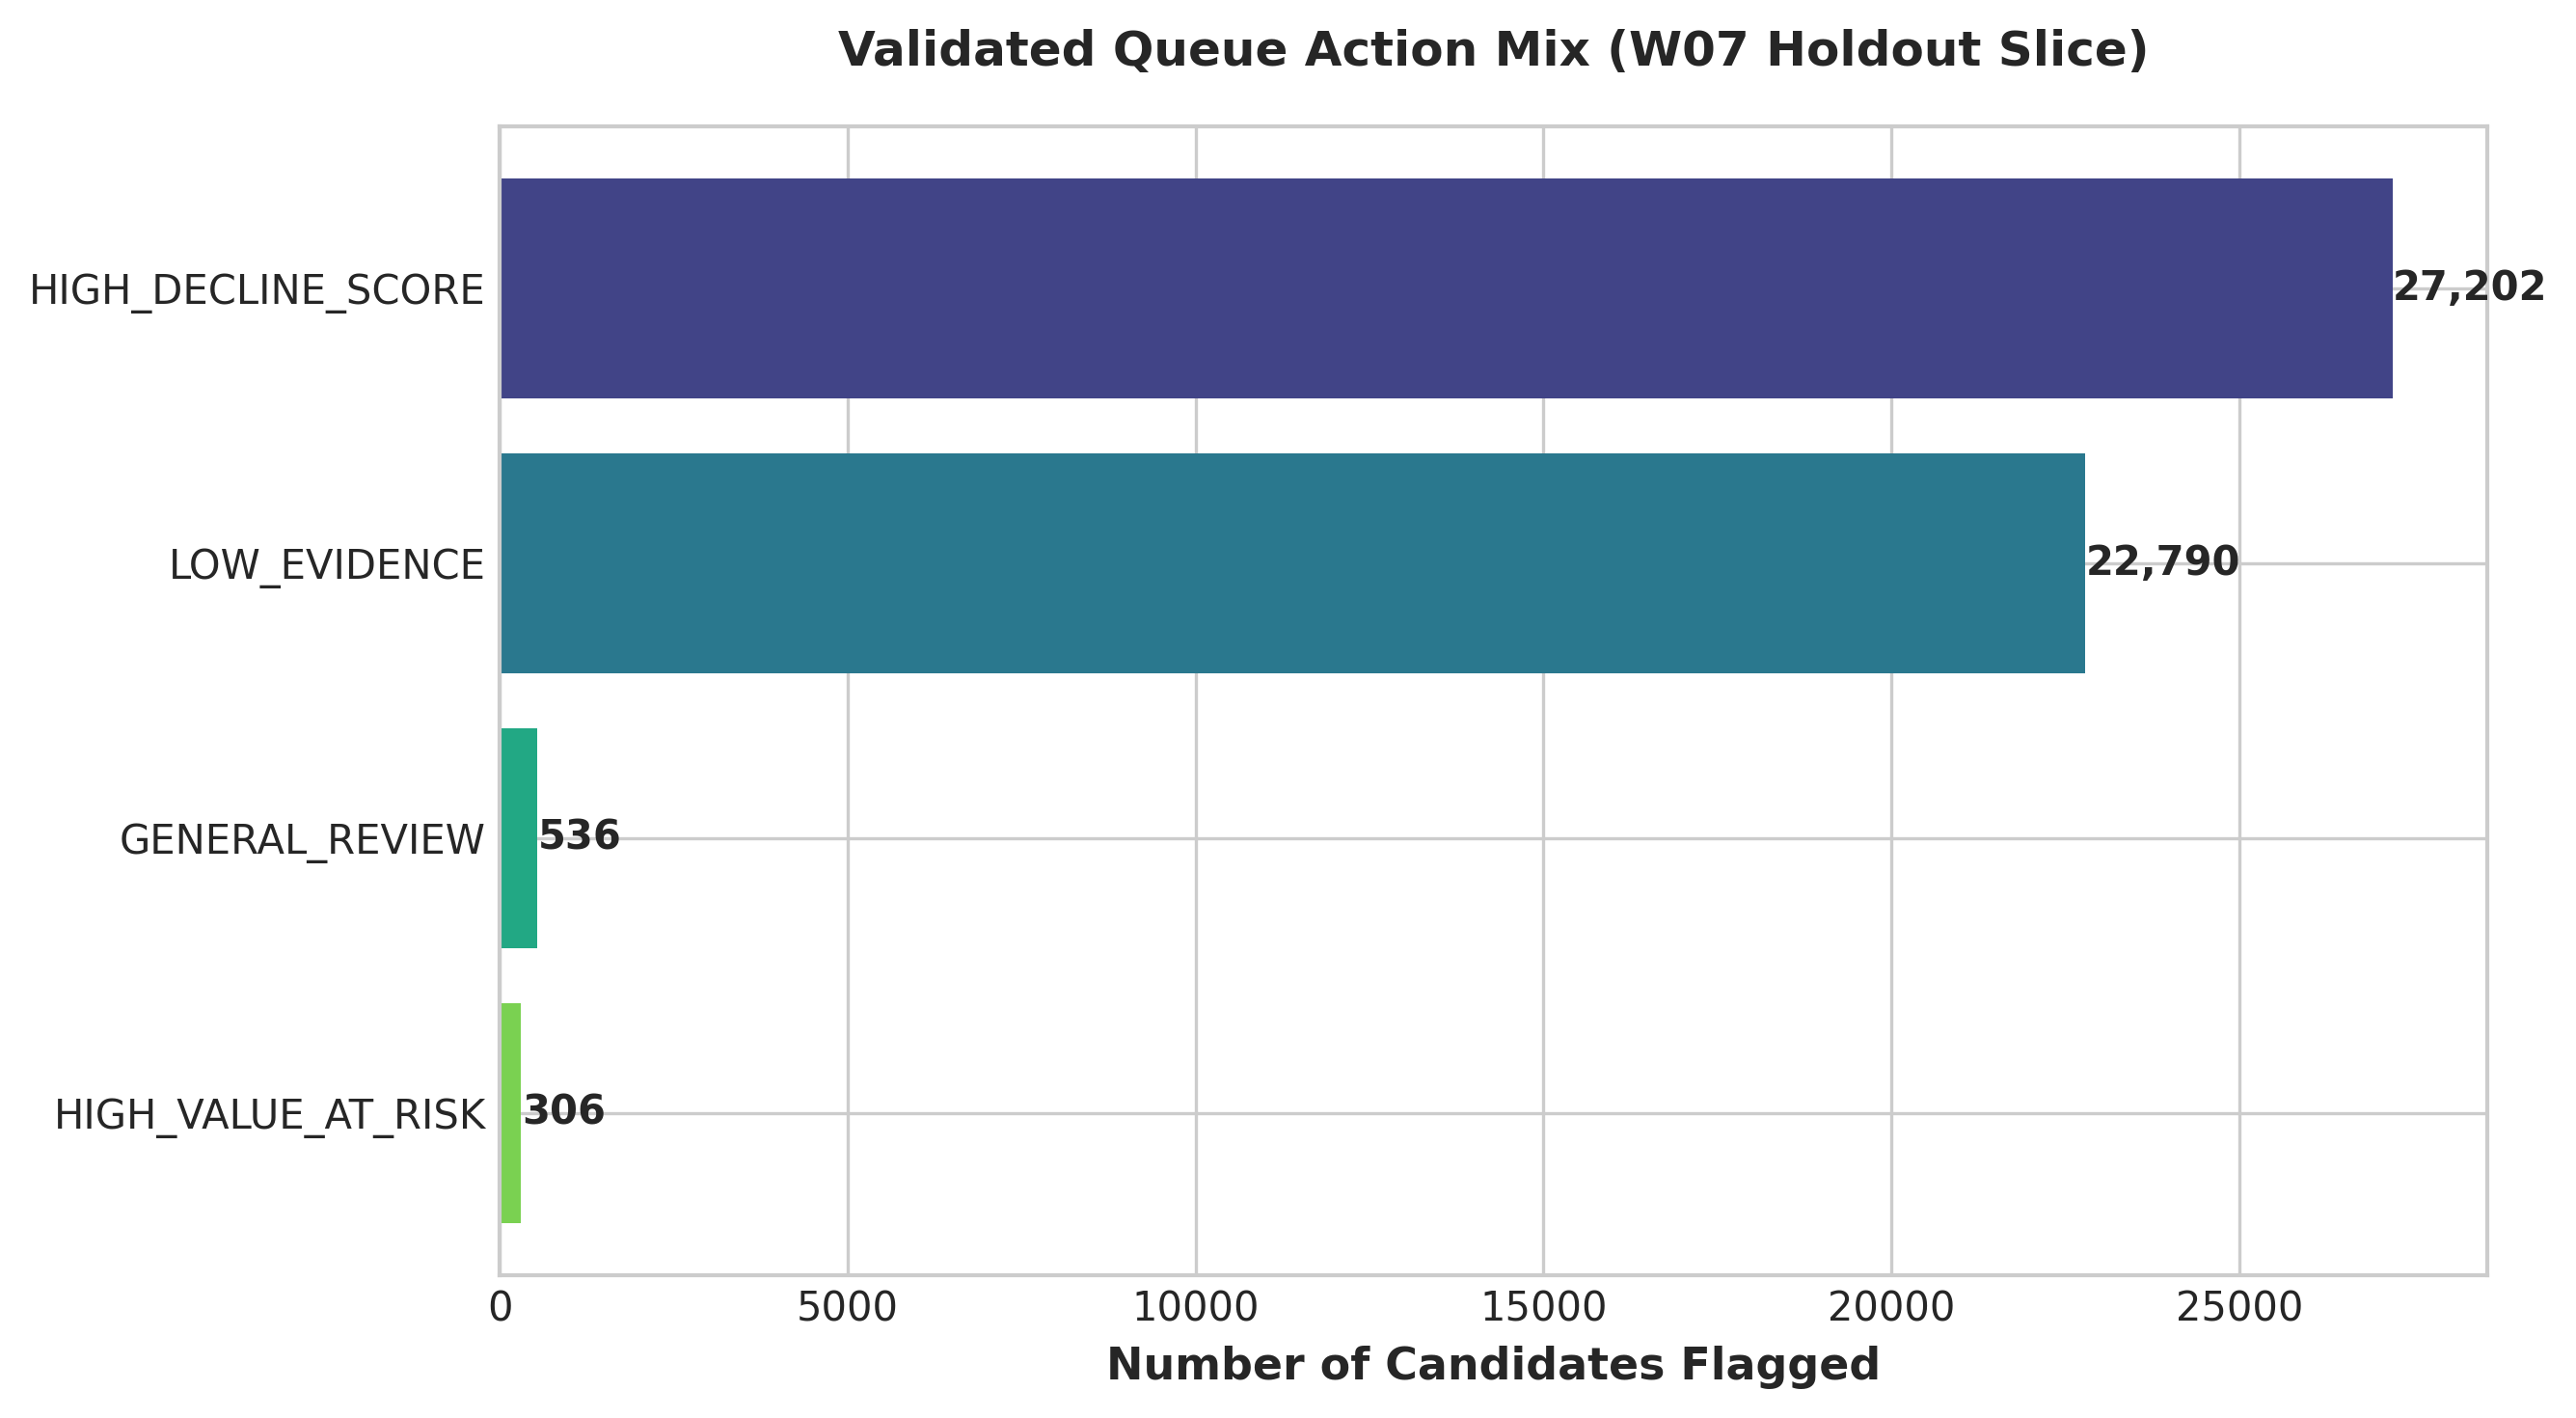

--- TOP 5 RANKED REVIEW CANDIDATES ---
         content_hash_id  decline_score        reason_code  search_volume  word_count
content_d5626328d0199632       0.919492 HIGH_DECLINE_SCORE            170           0
content_695fb13c42a38a74       0.915528 HIGH_DECLINE_SCORE              0         798
content_695fb13c42a38a74       0.915528 HIGH_DECLINE_SCORE              0         798
content_5a428e7e1dd756a6       0.912281 HIGH_VALUE_AT_RISK          12100           0
content_0bc57e8596bd0e24       0.908336 HIGH_VALUE_AT_RISK           9900           0


In [6]:
# Create ranked decision queue with reason codes
df_queue = X_test.copy()
df_queue['decline_score'] = y_probs
df_queue['client_hash_id'] = test_groups
df_queue['content_hash_id'] = df_ml.iloc[test_idx]['content_hash_id']

# Assign Reason Codes based on Rule-and-Score Playbook
def assign_reason_code(row):
    if row['decline_score'] >= 0.70 and row['search_volume'] > 1000:
        return 'HIGH_VALUE_AT_RISK'
    elif row['decline_score'] >= 0.60:
        return 'HIGH_DECLINE_SCORE'
    elif row['hist_7d_avg_clicks'] > 10 and row['word_count'] < 800:
        return 'THIN_VISIBLE'
    elif row['hist_7d_avg_clicks'] > 5:
        return 'AGING_VISIBLE'
    elif row['decline_score'] < 0.30:
        return 'LOW_EVIDENCE'
    else:
        return 'GENERAL_REVIEW'

df_queue['reason_code'] = df_queue.apply(assign_reason_code, axis=1)

# Generate Chart 2: action_mix.png
action_counts = df_queue['reason_code'].value_counts()

plt.figure(figsize=(9, 5))
palette = sns.color_palette("viridis", len(action_counts))
bars = plt.barh(action_counts.index, action_counts.values, color=palette)
plt.xlabel('Number of Candidates Flagged', fontsize=11, fontweight='bold')
plt.title('Validated Queue Action Mix (W07 Holdout Slice)', fontsize=12, fontweight='bold', pad=15)
plt.gca().invert_yaxis()

for bar in bars:
    xval = bar.get_width()
    plt.text(xval + 5, bar.get_y() + bar.get_height()/2.0, f"{int(xval):,}", ha='left', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("--- TOP 5 RANKED REVIEW CANDIDATES ---")
print(df_queue[['content_hash_id', 'decline_score', 'reason_code', 'search_volume', 'word_count']]
      .sort_values(by='decline_score', ascending=False)
      .head(5)
      .to_string(index=False))

## 7. Artifacts the paper embeds

- `work/figures/precision_comparison.png` — exploratory versus grouped Precision@50.
- `work/figures/action_mix.png` — validated queue action mix.
- `work/outputs/w07_validation_metrics.json` — validation receipt generated by W07.

### 5-minute demo outline
1. State the review-capacity problem.
2. Show the temporal wall and grouped validation design.
3. Show Precision@50 and explain why W05's 0.9400 is not the headline.
4. Show reason codes and action mapping.
5. End with limitations and the human-review boundary.

### Social-post cut
I built a leakage-aware content-review ranking workflow on FlyRank's pseudonymized internship warehouse. Under client-grouped validation, the final audit slice measured 0.7223 ROC AUC, 0.5647 average precision, and 0.5200 Precision@50. The output is a human-review queue with reason codes—not an automated promise that a refresh will recover traffic.

### Employer-facing summary
I built and validated a ranking pipeline that prioritizes content pages for human review using historical search/content signals. I used grouped client holdout validation and an explicit temporal leakage audit rather than relying on a random row split. The final result is decision support with reason codes and monitoring triggers, with clear boundaries around what the data cannot prove.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
